<a href="https://colab.research.google.com/github/Lalepragati/ML/blob/main/ANN-Optical_Character_Recognition_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Recognize optical character using ANN

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
# importing dataset
digit_mnist = keras.datasets.mnist
(x_train_full, y_train_full), (x_test, y_test) = digit_mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train_full.shape

(60000, 28, 28)

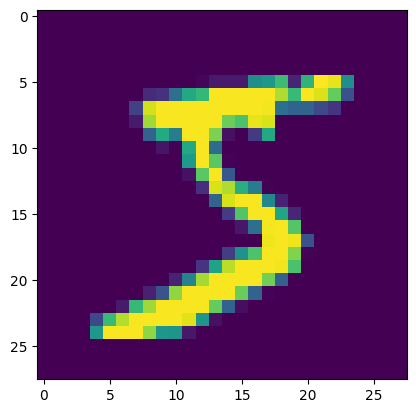

In [4]:
plt.imshow(x_train_full[0])

In [5]:
# feature scaling
x_train_n = x_train_full / 255.
x_test_n = x_test / 255.

In [6]:
# Train_Valid_Test Split
x_valid, x_train = x_train_n[:6000],x_train_n[6000:]
y_valid, y_train = y_train_full[:6000],y_train_full[6000:]
x_test = x_test_n

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# Model Building
model = keras.models.Sequential()

model.add(keras.layers.Flatten(input_shape=[28,28]))

model.add(keras.layers.Dense(200,activation='relu'))

model.add(keras.layers.Dense(100,activation='relu'))


model.add(keras.layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(loss='sparse_categorical_crossentropy',
             metrics=['accuracy'],
             optimizer = 'sgd')

In [11]:
# model training
model_r = model.fit(x_train,y_train,epochs=10,
                         validation_data=(x_valid,y_valid))

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9622 - loss: 0.1344 - val_accuracy: 0.9615 - val_loss: 0.1323
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9660 - loss: 0.1227 - val_accuracy: 0.9633 - val_loss: 0.1234
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9692 - loss: 0.1126 - val_accuracy: 0.9657 - val_loss: 0.1160
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9718 - loss: 0.1038 - val_accuracy: 0.9673 - val_loss: 0.1096
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0962 - val_accuracy: 0.9687 - val_loss: 0.1042
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9761 - loss: 0.0894 - val_accuracy: 0.9700 - val_loss: 0.0996
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9776 - loss: 0.0834 - val_accuracy: 0.9722 - val_loss: 0.0954
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9792 - loss: 0.0779 - 

In [12]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.0885


[0.08854958415031433, 0.9718999862670898]

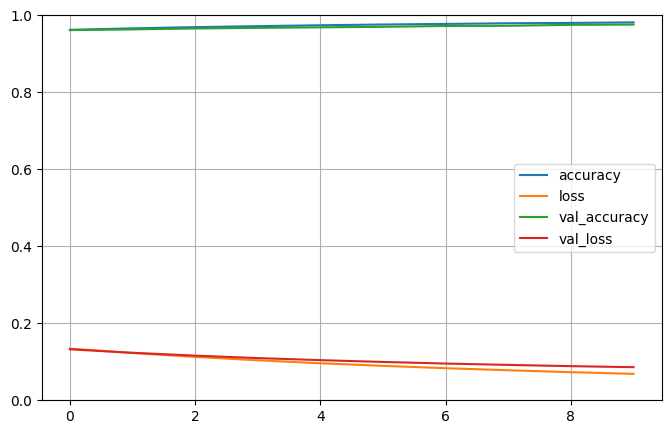

In [16]:
pd.DataFrame(model_r.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [17]:
# predicting first five Digits
x_new=x_test[:5]

In [18]:
y_proba = model.predict(x_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.  , 0.01]],
      dtype=float32)

In [19]:
predict_x = model.predict(x_new)
classes_x=np.argmax(predict_x,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [20]:
# Output
classes_x

array([7, 2, 1, 0, 4])